# 08 — Credit risk and portfolio

This notebook treats the Ames houses as a mortgage book and asks what the AVM's valuation errors cost a lender. A lender originates against a valuation rather than a sale price, so AVM error is the first term in the loan-to-value ratio (LTV: the loan as a percentage of the property's value, so an 80% LTV loan on a $300k house is a $240k loan), which drives probability of default and expected loss. An AVM that is 8% too generous on a segment writes 80% LTV loans that are really 87% LTV loans, and nobody finds out until prices fall. Using the 862 out-of-sample properties from notebook 03, the FHFA Ames price path and the recalibrated conformal intervals from notebook 05, the headline result (§5) is that marking collateral at the cautious end of the model's own interval adds 85% to expected loss. Losses are also stressed at the supervisory −30% house-price shock, and results are quoted in basis points (88 bps = 0.88%).

Terms are defined in [the glossary](../docs/GLOSSARY.md).

The notebook proceeds in five steps:

1. Originate a loan book at 80% LTV **on the AVM value**, and measure the true LTV.
2. Mark it to market along the FHFA Ames path and track negative equity (loan larger than the house's value).
3. Compute expected loss as PD × LGD × EAD (probability of default × loss given default × exposure at default), stressed at the −30% shock.
4. Propagate the conformal interval width into LGD, so AVM uncertainty becomes a credit-risk input in basis points.
5. Measure concentration: neighborhood risk and return, with a caveat about the short panel.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ames.compat import silence_spurious_matmul_warnings
from ames.config import (ARMS_LENGTH_CONDITION, CCAR_SEVERELY_ADVERSE_HPI_SHOCK,
                         CONFORMAL_ALPHA, PROCESSED, SEED)
from ames.avm import MondrianConformal
from ames.data import load_macro, load_properties
from ames.features import prepare
from ames.risk import (apply_hpi_shock, expected_loss, lgd_from_ltv,
                       lgd_with_valuation_uncertainty, mark_to_market,
                       neighborhood_risk_return, negative_equity_share, originate,
                       pd_from_ltv, portfolio_summary, stress_grid, uncertainty_cost)
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "08 · Credit risk"
SOURCE = "Sources: De Cock (2011), Federal Reserve supervisory scenario · author's calculations."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

intervals = pd.read_parquet(PROCESSED / "avm_intervals.parquet")
conformal = json.loads((PROCESSED / "conformal.json").read_text())
governance = json.loads((PROCESSED / "governance_summary.json").read_text())
macro = load_macro()
props = prepare(load_properties())

# The served interval: Mondrian bands recalibrated on the latest twelve months of closed
# sales (notebook 05) -- one half-width per valuation band, so each loan carries its own.
# The same bands calibrated once at launch (notebook 04) are kept for comparison.
served = MondrianConformal.from_dict(json.loads((PROCESSED / "recalibration.json").read_text()))
log_value = np.log(intervals["predicted"].to_numpy())
Q_LOAN = served.half_width(log_value)
Q_LAUNCH = intervals["q_mondrian"].to_numpy()
print(f"{len(intervals):,} properties with out-of-sample AVM values")
print(f"{1 - CONFORMAL_ALPHA:.0%} interval as served, by valuation band (cheapest first):")
loans_per_band = pd.Series(served.band(log_value) + 1).value_counts()
for b, q in enumerate(served.to_dict()["q_by_band"], start=1):
    print(f"  band {b}: q = {q:.4f}  ->  ×{np.exp(-q):.3f} to ×{np.exp(q):.3f}  "
          f"({loans_per_band.get(b, 0)} loans)")

862 properties with out-of-sample AVM values
80% interval as served, by valuation band (cheapest first):
  band 1: q = 0.1491  ->  ×0.862 to ×1.161  (153 loans)
  band 2: q = 0.1287  ->  ×0.879 to ×1.137  (180 loans)
  band 3: q = 0.1043  ->  ×0.901 to ×1.110  (159 loans)
  band 4: q = 0.1254  ->  ×0.882 to ×1.134  (178 loans)
  band 5: q = 0.1154  ->  ×0.891 to ×1.122  (192 loans)


## 1. Originating against the AVM

**Only out-of-sample AVM values are used.** The 862 properties here are the 2009–2010 temporal test set from notebook 03; the model never saw their prices. Originating against in-sample predictions would understate AVM error by an order of magnitude and make the exercise circular.

In [2]:
TARGET_LTV = 0.80

detail = props.set_index("PID").loc[intervals["PID"]]
book = originate(avm_value=intervals["predicted"].to_numpy(),
                 sale_price=intervals["actual"].to_numpy(),
                 target_ltv=TARGET_LTV)
book["PID"] = intervals["PID"].to_numpy()
book["Neighborhood"] = intervals["Neighborhood"].to_numpy()
book["sale_date"] = detail["sale_date"].to_numpy()
book["Yr Sold"] = detail["Yr Sold"].to_numpy()

origination = pd.Series({
    "loans originated": len(book),
    "total lending": book["loan_amount"].sum(),
    "underwritten LTV": TARGET_LTV,
    "mean true LTV": book["ltv_true"].mean(),
    "median true LTV": book["ltv_true"].median(),
    "share above 80% true LTV": (book["ltv_true"] > TARGET_LTV).mean(),
    "share above 90% true LTV": (book["ltv_true"] > 0.90).mean(),
    "share above 100% true LTV": (book["ltv_true"] > 1.00).mean(),
}).to_frame("value")
origination.round(4)

,value
loans originated,8.620000e+02
total lending,1.215148e+08
underwritten LTV,8.000000e-01
mean true LTV,8.036000e-01
median true LTV,7.909000e-01
share above 80% true LTV,4.466000e-01
share above 90% true LTV,1.044000e-01
share above 100% true LTV,2.670000e-02


  saved reports/figures/08_avm_error_to_ltv.png


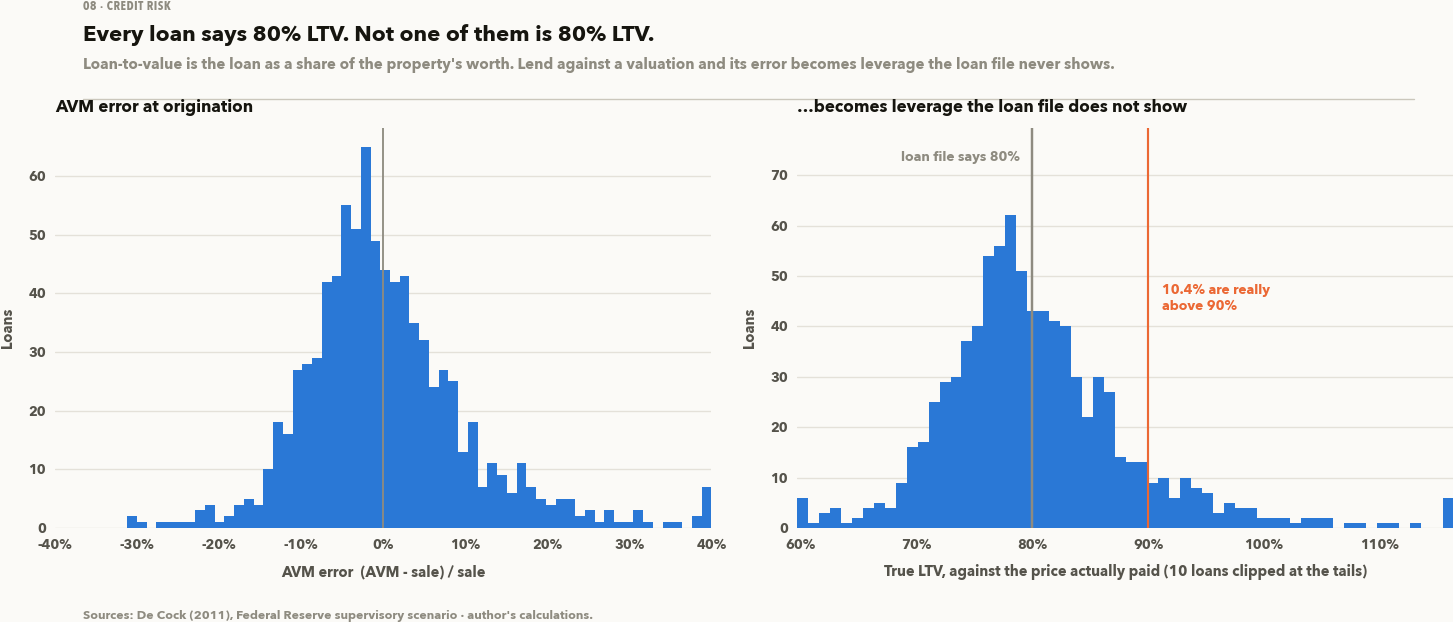

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))

axes[0].hist(book["valuation_error"].clip(-0.4, 0.4), bins=60, color=BLUE)
axes[0].axvline(0, color=INK_MUTED, lw=1.2)
axes[0].xaxis.set_major_formatter(pct)
axes[0].set_xlabel("AVM error  (AVM - sale) / sale")
axes[0].set_ylabel("Loans")
axes[0].set_xlim(-0.4, 0.4)
axes[0].set_title("AVM error at origination")

# Clipped to the 0.5-99.5 percentile so one 160% LTV outlier does not flatten the
# distribution; the count beyond the clip is stated rather than hidden.
lo, hi = book["ltv_true"].quantile([0.005, 0.995])
beyond = int((book["ltv_true"] > hi).sum() + (book["ltv_true"] < lo).sum())
axes[1].hist(book["ltv_true"].clip(lo, hi), bins=60, color=BLUE)
axes[1].set_xlim(lo, hi)
top = axes[1].get_ylim()[1]
axes[1].set_ylim(0, top * 1.22)

axes[1].axvline(TARGET_LTV, color=INK_MUTED, lw=1.6)
annotate(axes[1], TARGET_LTV, top * 1.13, f"loan file says {TARGET_LTV:.0%}",
         color=INK_MUTED, offset=(-8, 0), ha="right")
above = (book["ltv_true"] > 0.90).mean()
axes[1].axvline(0.90, color=STATUS["serious"], lw=1.4)
annotate(axes[1], 0.90, top * 0.70,
         f"{above:.1%} are really\nabove 90%", color=STATUS["serious"], offset=(9, 0))
axes[1].xaxis.set_major_formatter(pct)
axes[1].set_xlabel(f"True LTV, against the price actually paid "
                   f"({beyond} loans clipped at the tails)")
axes[1].set_ylabel("Loans")
axes[1].set_title("…becomes leverage the loan file does not show")

finish(fig, "Every loan says 80% LTV. Not one of them is 80% LTV.",
       "Loan-to-value is the loan as a share of the property's worth. Lend against a "
       "valuation and its error becomes leverage the loan file never shows.")
save(fig, "08_avm_error_to_ltv")
plt.show()

This chart shows the transmission channel. The loan file says 80% on every loan. The true leverage is a distribution centred near 80% and spread across roughly ±15 points, and the spread comes entirely from AVM error.

Reading an average LTV of 80% as the risk of an 80% LTV book is a Jensen's-inequality error: losses are convex in LTV, so a spread of LTVs around 80% is strictly riskier than every loan sitting at 80%.

## 2. Marking to market

Each loan is rolled forward along the FHFA Ames path from **its own origination date**, at the PMMS rate prevailing when it was written.

In [4]:
hpi = macro["hpi_ames_msa"].dropna()
pmms = macro["mortgage30us"].dropna() / 100

orig_month = pd.to_datetime(book["sale_date"]).dt.to_period("M").dt.to_timestamp()
book["hpi_at_origination"] = hpi.reindex(orig_month).to_numpy()
book["note_rate"] = pmms.reindex(orig_month).to_numpy()
print(f"note rates at origination: {book['note_rate'].min():.2%} – "
      f"{book['note_rate'].max():.2%} (median {book['note_rate'].median():.2%})")

VALUATION_DATES = ["2010-01-01", "2012-04-01", "2016-01-01", "2020-01-01",
                   str(hpi.index[-1].date())]

snapshots = {}
for date in VALUATION_DATES:
    ts = pd.Timestamp(date)
    months = ((ts.year - orig_month.dt.year) * 12 + (ts.month - orig_month.dt.month))
    factor = hpi.asof(ts) / book["hpi_at_origination"]
    rolled = mark_to_market(book, hpi_factor=factor.to_numpy(),
                            months_seasoned=months.clip(lower=0).to_numpy(),
                            mortgage_rate=book["note_rate"].to_numpy())
    snapshots[ts] = expected_loss(rolled)

path = pd.DataFrame({ts: portfolio_summary(s) for ts, s in snapshots.items()}).T
path.index = path.index.strftime("%Y-%m")
path.round(4)

note rates at origination: 4.56% – 5.42% (median 5.00%)


,n_loans,total_ead,total_collateral,weighted_mtm_ltv,negative_equity_share,weighted_pd,weighted_lgd,expected_loss,el_rate_bps
2010-01,862.0,1.208914e+08,1.495277e+08,0.8170,0.0348,0.0864,0.0833,1.344149e+06,111.1865
2012-04,862.0,1.168610e+08,1.513526e+08,0.7803,0.0209,0.0677,0.0521,7.600335e+05,65.0374
2016-01,862.0,1.087225e+08,1.713342e+08,0.6412,0.0012,0.0254,0.0040,6.130821e+04,5.6390
2020-01,862.0,9.817461e+07,1.983402e+08,0.5002,0.0012,0.0107,0.0002,5.241803e+03,0.5339
2026-09,862.0,7.512517e+07,2.978266e+08,0.2549,0.0000,0.0056,0.0000,0.000000e+00,0.0000


The 2012 column is the real trough; notebook 02 dated it to April 2012 in CPI-deflated terms. Even there, negative equity in Ames stays small. This is the acyclicality found in notebook 02, now visible in credit terms.

## 3. Expected loss

`EL = PD × LGD × EAD`, per loan.

**The PD curve is an assumed shape, not an estimate.** There are no default outcomes anywhere in the Ames data, so no PD model can be calibrated here and none is claimed. The logistic curve encodes the well-established empirical shape of mortgage default: near a floor while the borrower holds equity, steepening sharply as MTM LTV crosses 100% and the default option moves into the money, and saturating well below 100% because many underwater borrowers keep paying.

LGD is better grounded. `LGD = 1 − (1 − h)/MTM_LTV` with a 25% foreclosure-cost haircut, and notebook 01 gives partial support from this dataset: `Abnorml` sales (foreclosures and short sales) transacted **15% below** `Normal` sales per square foot. The remaining ~10 points cover legal, carrying and maintenance costs.

  saved reports/figures/08_loss_curves.png


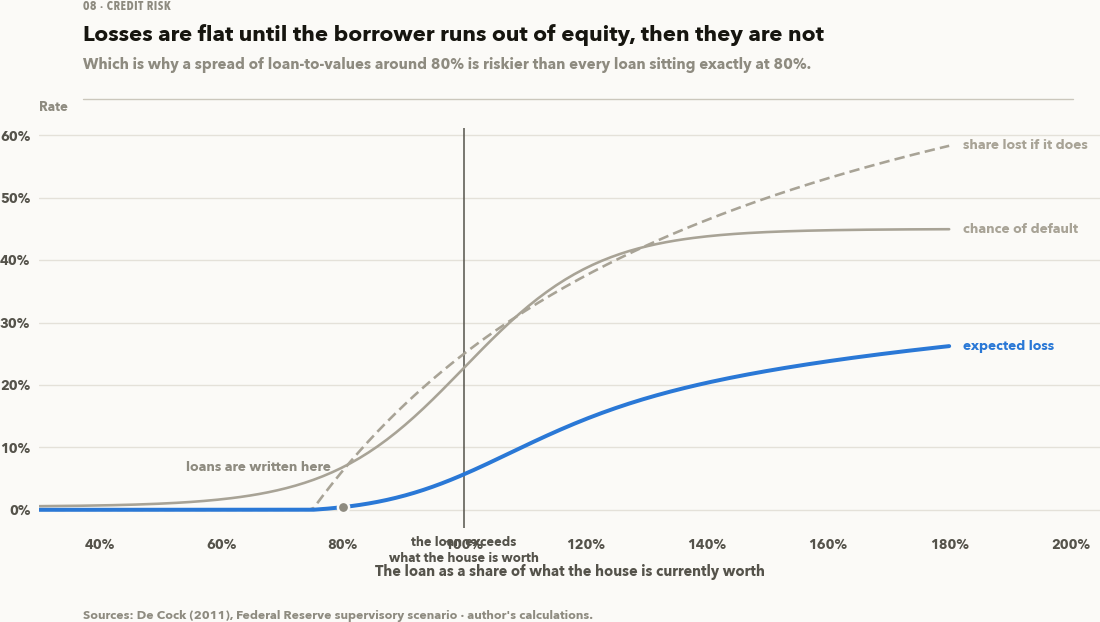

In [5]:
ltv_grid = np.linspace(0.3, 1.8, 200)
ltv_grid = np.linspace(0.3, 1.8, 200)
fig, ax = plt.subplots(figsize=(10.4, 6.2))
pd_curve, lgd_curve = pd_from_ltv(ltv_grid), lgd_from_ltv(ltv_grid)
loss_curve = pd_curve * lgd_curve
ax.plot(ltv_grid, pd_curve, color=CONTEXT_DARK, lw=1.7)
ax.plot(ltv_grid, lgd_curve, color=CONTEXT_DARK, lw=1.7, linestyle=(0, (4, 2)))
ax.plot(ltv_grid, loss_curve, color=SUBJECT, lw=2.6)
label_end(ax, ltv_grid[-1], pd_curve[-1], "chance of default", color=CONTEXT_DARK)
label_end(ax, ltv_grid[-1], lgd_curve[-1], "share lost if it does", color=CONTEXT_DARK)
label_end(ax, ltv_grid[-1], loss_curve[-1], "expected loss", color=SUBJECT)
reference_line(ax, 1.0, "the loan exceeds\nwhat the house is worth", axis="x",
               color=INK_SECONDARY, side="left")
annotate(ax, TARGET_LTV, loss_curve[np.abs(ltv_grid - TARGET_LTV).argmin()],
         "loans are written here", color=INK_MUTED, offset=(-8, 26), ha="right")
ax.scatter([TARGET_LTV], [loss_curve[np.abs(ltv_grid - TARGET_LTV).argmin()]], s=54,
           color=INK_MUTED, edgecolor=SURFACE, linewidths=1.6, zorder=5)
ax.set_xlim(0.3, 2.05)
ax.xaxis.set_major_formatter(pct)
ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("The loan as a share of what the house is currently worth")
axis_note(ax, "Rate")
finish(fig, "Losses are flat until the borrower runs out of equity, then they are not",
       "Which is why a spread of loan-to-values around 80% is riskier than every loan "
       "sitting exactly at 80%.")
save(fig, "08_loss_curves")
plt.show()

## 4. Stress: the supervisory severely adverse scenario

### Which book to stress

The 2009–2010 vintage is the wrong portfolio for this. By 2026 it has amortised for sixteen years while Ames prices roughly doubled, so its weighted MTM LTV is around 25% and its expected loss is negligible. A 30% shock moves LTV to roughly 36%, still far from the point where a lender loses money. The book would pass the stress test only because it is old.

A supervisory stress test (**CCAR**) applies to the portfolio as it stands today, which for any going concern is dominated by recent originations at current prices and leverage.

So the stress is run on a second book: the same properties, valued by the same AVM with the same measured error, originated **today** at 80% LTV. Sale prices and AVM values are both rolled forward on the FHFA path, which preserves each loan's valuation error while moving it to today's price level.

In [6]:
seasoned = snapshots[pd.Timestamp(VALUATION_DATES[-1])]
latest_factor = (hpi.iloc[-1] / book["hpi_at_origination"]).to_numpy()
current_rate = float(pmms.iloc[-1])

today = originate(avm_value=intervals["predicted"].to_numpy() * latest_factor,
                  sale_price=intervals["actual"].to_numpy() * latest_factor,
                  target_ltv=TARGET_LTV)
today["PID"] = book["PID"].to_numpy()
today["Neighborhood"] = book["Neighborhood"].to_numpy()

current = expected_loss(mark_to_market(today, hpi_factor=1.0, months_seasoned=0,
                                       mortgage_rate=current_rate))
stressed = apply_hpi_shock(current, CCAR_SEVERELY_ADVERSE_HPI_SHOCK)

book_compare = pd.DataFrame({
    "2009–10 vintage, seasoned to today": portfolio_summary(seasoned),
    "same properties, originated today": portfolio_summary(current),
}).T
book_compare.round(4)

,n_loans,total_ead,total_collateral,weighted_mtm_ltv,negative_equity_share,weighted_pd,weighted_lgd,expected_loss,el_rate_bps
"2009–10 vintage, seasoned to today",862.0,7.512517e+07,2.978266e+08,0.2549,0.0000,0.0056,0.000,0.000000e+00,0.000
"same properties, originated today",862.0,2.361981e+08,2.978266e+08,0.8013,0.0267,0.0779,0.069,2.089998e+06,88.485


**The same houses carry a completely different credit profile depending on when the loan was written.** Sixteen years of amortisation and appreciation give more protection than any underwriting standard. This is why a lender's risk is concentrated in its newest loans, and why a portfolio's average seasoning matters as much as its average LTV.

Everything from here uses the today-originated book.

In [7]:
# Notebook 02 measured what 410 US metros actually did in 2005-2013.  The -30%
# borrowed from the supervisory scenario turns out to sit at roughly the 19th
# percentile of that distribution: it is a convention, not a calibration.  Both are
# reported, because the gap between them is the cost of not checking.
metro = json.loads((PROCESSED / "metro_summary.json").read_text())
EMPIRICAL_SHOCK = metro["empirical_p10_shock"]
empirical = apply_hpi_shock(current, EMPIRICAL_SHOCK)

print(f"{metro['share_exceeding_imposed_shock']:.0%} of {metro['n_metros']} metros "
      f"exceeded the {CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%} scenario; a 10th-percentile "
      f"metro fell {EMPIRICAL_SHOCK:.0%}")

stress_compare = pd.DataFrame({
    "base": portfolio_summary(current),
    f"severely adverse, imposed ({CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%})":
        portfolio_summary(stressed),
    f"10th-percentile metro, measured ({EMPIRICAL_SHOCK:.0%})":
        portfolio_summary(empirical),
}).T
stress_compare["multiple"] = (stress_compare["expected_loss"]
                              / stress_compare["expected_loss"].iloc[0])
stress_compare.round(4)

19% of 410 metros exceeded the -30% scenario; a 10th-percentile metro fell -41%


,n_loans,total_ead,total_collateral,weighted_mtm_ltv,negative_equity_share,weighted_pd,weighted_lgd,expected_loss,el_rate_bps,multiple
base,862.0,2.361981e+08,2.978266e+08,0.8013,0.0267,0.0779,0.0690,2.089998e+06,88.4850,1.000
"severely adverse, imposed (-30%)",862.0,2.361981e+08,2.084786e+08,1.1447,0.9385,0.3370,0.3380,2.794545e+07,1183.1362,13.371
"10th-percentile metro, measured (-41%)",862.0,2.361981e+08,1.744194e+08,1.3683,0.9954,0.4237,0.4462,4.500403e+07,1905.3512,21.533


Two scenarios are shown.

The −30% decline is the supervisory severely adverse assumption, and it is what a committee expects to see. Notebook 02 checked it against history: **19% of 410 US metros fell further than that** between 2005 and 2013, and a 10th-percentile market fell **41%**. A decline that one market in five exceeded in that period is closer to a moderate scenario than a severe one.

Applying a round number from a national supervisory exercise to a single market is reasonable as a convention, since everyone knows what −30% means, but it is not a calibration for Ames. The gap between the two loss figures measures what the convention leaves out.

  saved reports/figures/08_stress_curve.png


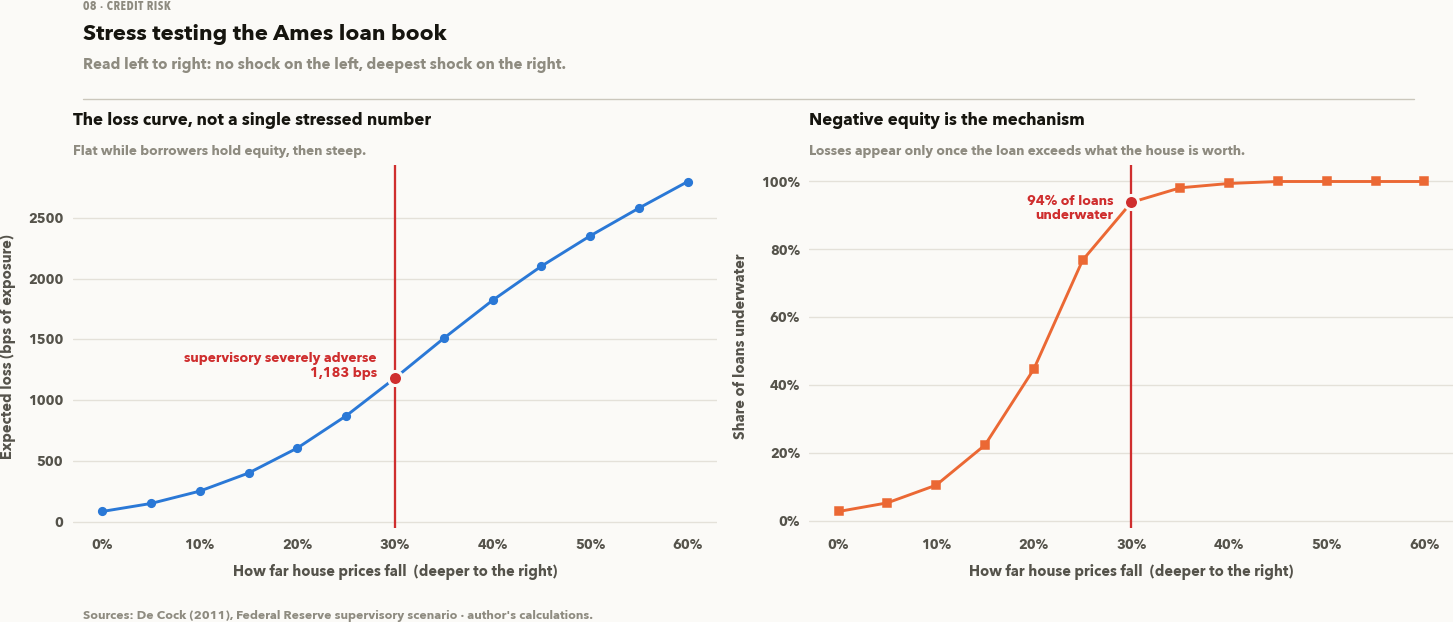

In [8]:
grid = stress_grid(current, np.arange(0.0, -0.61, -0.05))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.2))

# Plot severity left-to-right: no shock at the left, deepest shock at the right.  With
# the raw (negative) index on the x-axis the curve descends as you read rightwards, which
# makes rising losses look like falling ones.
severity = -grid.index.to_numpy()
ccar = -CCAR_SEVERELY_ADVERSE_HPI_SHOCK
at_ccar = int(np.abs(grid.index - CCAR_SEVERELY_ADVERSE_HPI_SHOCK).argmin())
ccar_el = grid["el_rate_bps"].iloc[at_ccar]
ccar_ne = grid["negative_equity_share"].iloc[at_ccar]

axes[0].plot(severity, grid["el_rate_bps"], color=BLUE, marker="o", markersize=5)
axes[0].axvline(ccar, color=STATUS["critical"], lw=1.5)
axes[0].scatter([ccar], [ccar_el], s=85, color=STATUS["critical"],
                edgecolor=SURFACE, linewidths=2, zorder=5)
annotate(axes[0], ccar, ccar_el,
         f"supervisory severely adverse\n{ccar_el:,.0f} bps",
         color=STATUS["critical"], offset=(-12, 8), ha="right")
axes[0].xaxis.set_major_formatter(pct)
axes[0].set_xlabel("How far house prices fall  (deeper to the right)")
axes[0].set_ylabel("Expected loss (bps of exposure)")
titled(axes[0], "The loss curve, not a single stressed number",
       "Flat while borrowers hold equity, then steep.")

axes[1].plot(severity, grid["negative_equity_share"], color=ORANGE, marker="s",
             markersize=5)
axes[1].axvline(ccar, color=STATUS["critical"], lw=1.5)
axes[1].scatter([ccar], [ccar_ne], s=85, color=STATUS["critical"],
                edgecolor=SURFACE, linewidths=2, zorder=5)
annotate(axes[1], ccar, ccar_ne, f"{ccar_ne:.0%} of loans\nunderwater",
         color=STATUS["critical"], offset=(-12, -4), ha="right")
axes[1].xaxis.set_major_formatter(pct)
axes[1].yaxis.set_major_formatter(pct)
axes[1].set_xlabel("How far house prices fall  (deeper to the right)")
axes[1].set_ylabel("Share of loans underwater")
titled(axes[1], "Negative equity is the mechanism",
       "Losses appear only once the loan exceeds what the house is worth.")

finish(fig, "Stress testing the Ames loan book",
           "Read left to right: no shock on the left, deepest shock on the right.")
save(fig, "08_stress_curve")
plt.show()

The shape of the curve matters more than any single point. Loss is **non-linear in the shock**: flat while borrowers hold equity, then steepening once a material share of the book crosses zero equity. A committee that only sees the −30% number cannot tell whether it sits on the flat part or near the steep part.

## 5. AVM uncertainty as a credit-risk input

Every loss figure above marks collateral at the AVM's **point estimate**, which implicitly assumes the AVM is exactly right.

Notebook 04 quantifies how wrong it might be: the 80% conformal interval is a multiplicative band around the point estimate, with a width set per valuation band and re-fitted each quarter on the latest closed sales (the interval the service quotes). Marking collateral at the **conservative end of the model's own interval** is a prudent haircut. The difference between the two expected-loss figures is the dollar cost of valuation uncertainty.

In [9]:
uncertainty = pd.DataFrame({
    "base (no shock)": uncertainty_cost(current, Q_LOAN),
    f"severely adverse ({CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%})": uncertainty_cost(stressed, Q_LOAN),
}).T
# The same charge under the bands calibrated once at launch, to show what recalibration changed.
uncertainty_launch = pd.DataFrame({
    "base (no shock)": uncertainty_cost(current, Q_LAUNCH),
    f"severely adverse ({CCAR_SEVERELY_ADVERSE_HPI_SHOCK:.0%})": uncertainty_cost(stressed, Q_LAUNCH),
}).T
uncertainty.round(2)

,conformal_half_width,interval_ratio,el_point_estimate,el_conservative,el_uplift,el_uplift_bps
base (no shock),0.12,1.13,2089998.33,3873267.28,1783268.95,75.5
severely adverse (-30%),0.12,1.13,27945449.19,33840954.19,5895505.00,249.6


  saved reports/figures/08_uncertainty_cost.png


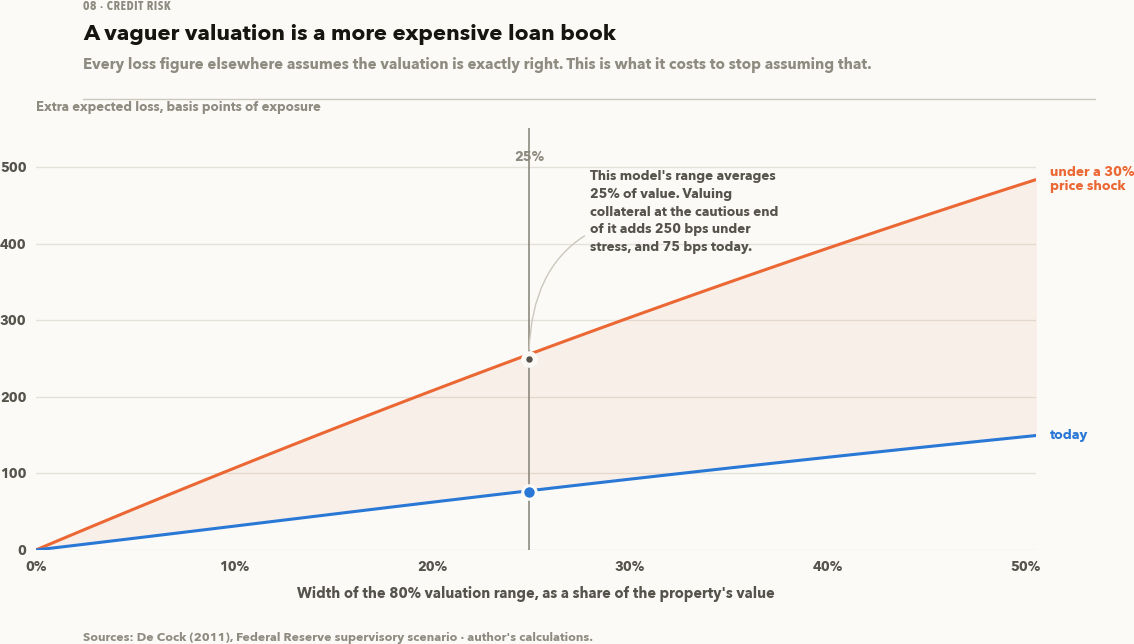

In [10]:
widths = np.linspace(0.0, 0.25, 40)
uplift = pd.DataFrame([
    {"q": q,
     "interval_width_pct": np.exp(q) - np.exp(-q),
     "base": uncertainty_cost(current, q)["el_uplift_bps"],
     "stressed": uncertainty_cost(stressed, q)["el_uplift_bps"]}
    for q in widths
]).set_index("interval_width_pct")

fig, ax = plt.subplots(figsize=(10.6, 6.4))

# The curve sweeps one width applied to every loan.  The model's own interval varies by
# band, so its point sits at the book's mean width and need not lie exactly on the curve.
actual_width = float(np.mean(np.exp(Q_LOAN) - np.exp(-Q_LOAN)))
base_at = uncertainty_cost(current, Q_LOAN)["el_uplift_bps"]
stress_at = uncertainty_cost(stressed, Q_LOAN)["el_uplift_bps"]

ax.plot(uplift.index, uplift["stressed"], color=CONTRAST, lw=2.0)
ax.plot(uplift.index, uplift["base"], color=SUBJECT, lw=2.0)
ax.fill_between(uplift.index, uplift["base"], uplift["stressed"],
                color=CONTRAST, alpha=0.07, lw=0)
label_end(ax, uplift.index[-1], uplift["stressed"].iloc[-1],
          f"under a {abs(CCAR_SEVERELY_ADVERSE_HPI_SHOCK):.0%}\nprice shock",
          color=CONTRAST, va="center")
label_end(ax, uplift.index[-1], uplift["base"].iloc[-1], "today", color=SUBJECT)

ax.axvline(actual_width, color=INK_MUTED, lw=1.1)
for val, colour in ((stress_at, CONTRAST), (base_at, SUBJECT)):
    ax.scatter([actual_width], [val], s=78, color=colour,
               edgecolor=SURFACE, linewidths=2, zorder=5)
callout(ax, actual_width, stress_at,
        f"This model's range averages {actual_width:.0%} of value. Valuing "
        f"collateral at the cautious end of it adds {stress_at:,.0f} bps under stress, "
        f"and {base_at:,.0f} bps today.",
        dx=40, dy=96, width=30)
annotate(ax, actual_width, uplift["stressed"].max() * 1.06,
         f"{actual_width:.0%}", color=INK_MUTED, offset=(0, 0), ha="center")

ax.set_xlim(0, uplift.index.max())
ax.set_ylim(0, uplift["stressed"].max() * 1.14)
ax.xaxis.set_major_formatter(pct)
ax.set_xlabel("Width of the 80% valuation range, as a share of the property's value")
axis_note(ax, "Extra expected loss, basis points of exposure")
finish(fig, "A vaguer valuation is a more expensive loan book",
       "Every loss figure elsewhere assumes the valuation is exactly right. This is what "
       "it costs to stop assuming that.")
save(fig, "08_uncertainty_cost")
plt.show()

In [11]:
base_uplift = uncertainty.loc["base (no shock)", "el_uplift_bps"]
stress_uplift = uncertainty.iloc[1]["el_uplift_bps"]
base_uplift_launch = uncertainty_launch.loc["base (no shock)", "el_uplift_bps"]
stress_uplift_launch = uncertainty_launch.iloc[1]["el_uplift_bps"]
print(f"AVM interval width (mean):              {actual_width:.1%} of value")
print(f"EL uplift from marking conservatively:  {base_uplift:,.0f} bps (base)")
print(f"                                        {stress_uplift:,.0f} bps (severely adverse)")
print(f"under the bands calibrated at launch:   {base_uplift_launch:,.0f} bps (base), "
      f"{stress_uplift_launch:,.0f} bps (severely adverse)")
print(f"\nFor context, base expected loss is       "
      f"{portfolio_summary(current)['el_rate_bps']:,.0f} bps")

AVM interval width (mean):              24.9% of value
EL uplift from marking conservatively:  75 bps (base)
                                        250 bps (severely adverse)
under the bands calibrated at launch:   65 bps (base), 216 bps (severely adverse)

For context, base expected loss is       88 bps


AVM quality control therefore has a direct credit-risk consequence. The interagency AVM rule's first factor is "a high level of confidence in the estimates produced", and the chart above prices that factor: halve the interval width and the required capital cushion falls with it, roughly linearly in the width and much more steeply under stress.

This also gives the modelling work in notebook 03 a financial measure. A narrower interval lowers expected loss on the loan book, and that saving, in basis points rather than R², is what justifies spending on data and modelling.

## 6. Concentration

A portfolio of 862 loans in one city does not get the diversification its loan count implies. The properties share a single local economy, and notebook 04 found the AVM's errors are spatially autocorrelated (Moran's I = 0.114, p < 1e-12), so the valuation noise is correlated as well as the prices.

In [12]:
arms_length = props[props["Sale Condition"] == ARMS_LENGTH_CONDITION]
risk_return = neighborhood_risk_return(arms_length, min_n=30)
risk_return.round(4)

,Neighborhood,n_sales,n_years,median_price,mean_annual_growth,growth_volatility,total_growth
0,ClearCr,38,5,218000.0,0.0805,0.2576,0.2484
1,Crawfor,88,5,198000.0,0.0787,0.3011,0.2047
2,Somerst,114,5,222250.0,0.0550,0.2417,0.1498
3,Mitchel,101,5,156000.0,0.0356,0.0717,0.1419
4,IDOTRR,68,5,116250.0,0.0351,0.1679,0.1055
5,BrkSide,98,5,127750.0,0.0339,0.0976,0.1275
6,NWAmes,117,5,185000.0,0.0274,0.0376,0.1119
7,NAmes,395,5,141000.0,0.0175,0.0263,0.0707
8,OldTown,204,5,122125.0,0.0174,0.0816,0.0609
9,Timber,52,5,220000.0,0.0140,0.3055,-0.0838


In [13]:
# The correlation matrix is computed to report its summary, not to draw it -- see the
# note below on why a heatmap of these numbers would mislead.
pivot = (arms_length.pivot_table(index="Yr Sold", columns="Neighborhood",
                                 values="SalePrice", aggfunc="median")
         .loc[:, risk_return["Neighborhood"]].pct_change().dropna(how="all"))
corr = pivot.corr()
off_diagonal = corr.to_numpy()[np.triu_indices_from(corr, k=1)]
print(f"neighborhoods with >= 30 sales:   {len(risk_return)}")
print(f"annual growth observations each:  {pivot.shape[0]}")
print(f"mean pairwise correlation:        {np.nanmean(off_diagonal):.3f}")
print(f"share of pairs above +0.5:        {np.nanmean(off_diagonal > 0.5):.1%}")

neighborhoods with >= 30 sales:   20
annual growth observations each:  4
mean pairwise correlation:        0.032
share of pairs above +0.5:        31.6%


### Why there is no chart here

**This table can suggest hypotheses but cannot measure risk.** The data spans five calendar years, which gives **four** annual growth rates per neighborhood. A standard deviation computed from four numbers has an enormous standard error, and a correlation matrix estimated from four observations across a dozen neighborhoods is close to noise: the sample correlation of two four-point series has a standard error around 0.5.

An earlier draft plotted a 20x20 correlation heatmap of those growth rates. It looked authoritative, but every cell rested on four observations, so it was cut. The table stays because it points to neighborhoods worth a closer look, and it shows the method one would apply to a twenty-year panel.

The fix is county assessor sale records back to the 1990s, which are public. That is the most valuable data addition for the credit work, well ahead of any modelling change.

## 7. Persist

In [14]:
current.assign(PID=book["PID"].to_numpy(),
               Neighborhood=book["Neighborhood"].to_numpy()).to_parquet(
    PROCESSED / "loan_book.parquet", index=False)

(PROCESSED / "credit_summary.json").write_text(json.dumps({
    "n_loans": int(len(book)),
    "target_ltv": TARGET_LTV,
    "mean_true_ltv": float(book["ltv_true"].mean()),
    "share_true_ltv_above_90": float((book["ltv_true"] > 0.90).mean()),
    "base_el_bps": float(portfolio_summary(current)["el_rate_bps"]),
    "stressed_el_bps": float(portfolio_summary(stressed)["el_rate_bps"]),
    "stress_multiple": float(stress_compare["multiple"].iloc[1]),
    "base_negative_equity": float(negative_equity_share(current)),
    "stressed_negative_equity": float(negative_equity_share(stressed)),
    "avm_interval_width": float(actual_width),
    "uncertainty_uplift_base_bps": float(base_uplift),
    "uncertainty_uplift_stressed_bps": float(stress_uplift),
    "interval_method": "mondrian_by_valuation_recalibrated_quarterly",
    "uncertainty_uplift_base_bps_launch_calibration": float(base_uplift_launch),
    "uncertainty_uplift_stressed_bps_launch_calibration": float(stress_uplift_launch),
    "n_neighborhoods": int(len(risk_return)),
    "mean_pairwise_correlation": float(np.nanmean(off_diagonal)),
}, indent=2))
print("wrote loan_book.parquet and credit_summary.json")

wrote loan_book.parquet and credit_summary.json


## 8. Summary

| Finding | Why it matters |
|---|---|
| Every loan reads 80% LTV; true LTV spreads roughly ±15 points around it | The spread comes entirely from AVM error, and because losses are convex in LTV the spread adds risk |
| The same houses carry very different risk depending on loan vintage | Seasoning and appreciation protect a book more than underwriting standards do |
| Expected loss rises sharply under the supervisory −30% shock on a freshly-originated book | Ames's own history has no downturn to learn from, so the stress must be imposed |
| Loss is non-linear in the shock | The loss curve shows a committee where the book sits relative to the steep part; a single stressed number does not |
| Marking collateral at the conservative end of the AVM interval adds materially to expected loss | **AVM uncertainty is a credit-risk input.** Narrower intervals reduce expected loss, measurable in basis points |
| Neighborhood growth correlations are indistinguishable from noise on a four-observation panel | The limitation is stated alongside the table in §6 |

### What to build next, in order

1. **Spatial structure in the AVM**: school attendance boundaries, arterial frontage. Notebook 04's Moran's I says location is the largest missing signal; notebook 03 §9 showed a spatial lag of prior nearby prices does not supply it.
2. **County assessor records back to the 1990s**: a real panel, which would turn §6 from an illustration into a measurement.
3. **A calibrated PD curve** from public loan-performance data. The shape used here is reasonable; a calibrated curve would make the basis-point figures quotable rather than indicative.
4. **A shorter or weighted recalibration window.** Quarterly recalibration on the last twelve months (notebook 05) lifts interval coverage from 77% to 79%; the remaining question is the trade between recency and stability.